In [15]:
import random

import joblib
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error as mae, PredictionErrorDisplay

In [2]:
x = np.linspace(1, 10, 100)
noise = np.random.normal(scale=2, size=x.shape)
a, b = random.randint(-10, 10), random.randint(-10, 10)
y = a*x + b + noise

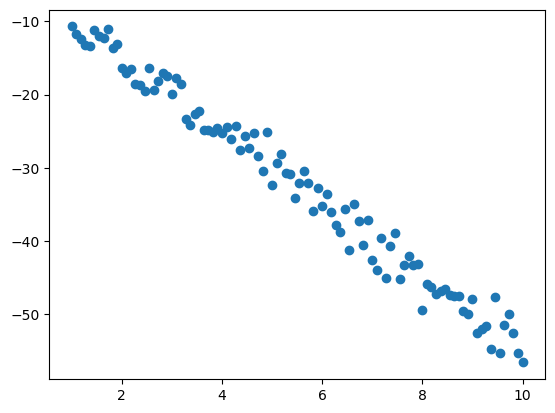

In [3]:
plt.scatter(x, y);

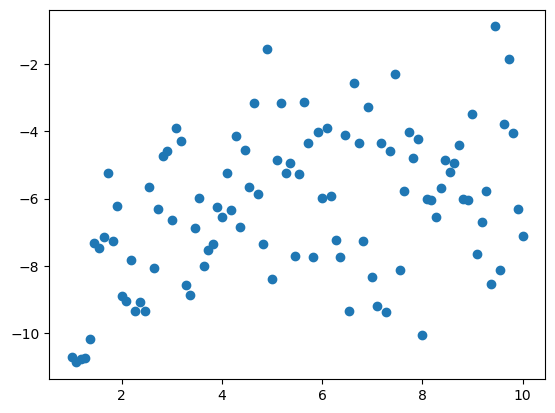

In [4]:
y1 = a/x + b + noise
plt.scatter(x, y1);

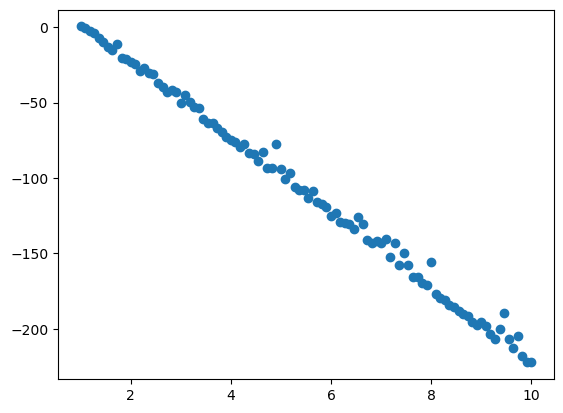

In [5]:
y2 = -a**2*x+b**2+noise**2
plt.scatter(x, y2);

In [6]:
y1 = y.copy()
y1[40:65] = y[40:65] * 5
# y1[40:65] = y1[40:65] * 5
# y2[40:65] = y2[40:65] * 5

In [7]:
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

LinearRegression()

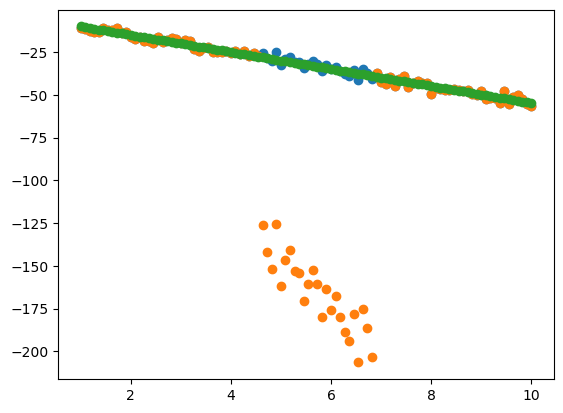

In [10]:
plt.scatter(x, y)
plt.scatter(x, y1)
plt.scatter(x, pred);

In [9]:
pred = model.predict(x.reshape(-1, 1))

In [11]:
mae(y, pred)

1.5549526867832002

In [12]:
mae(y1, pred)

34.16993569817042

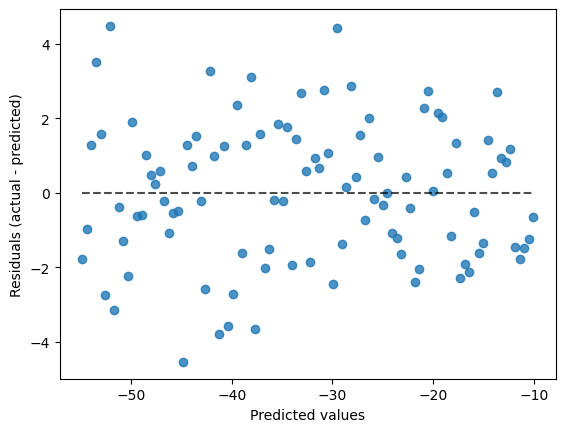

In [13]:
PredictionErrorDisplay.from_estimator(model, x.reshape(-1, 1), y);

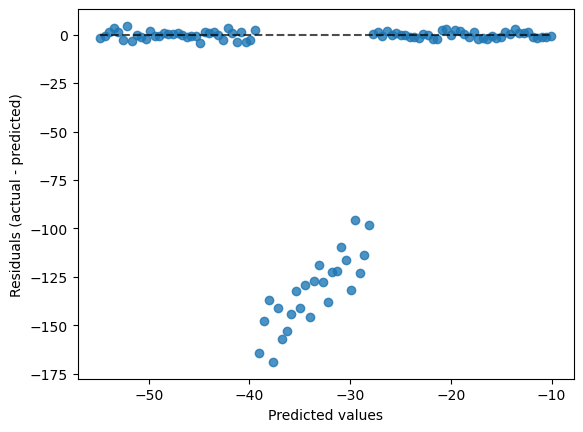

In [14]:
PredictionErrorDisplay.from_estimator(model, x.reshape(-1, 1), y1);

In [19]:
joblib.dump(model, 'model.joblib')

['model.joblib']

In [18]:
np.save('x.npy', x)
np.save('y.npy', y)
np.save('y1.npy', y1)

In [1]:
%%writefile test_model.py
import joblib
import numpy as np
import pytest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error as mae


@pytest.fixture
def y():
    return np.load('y.npy')
    


@pytest.fixture
def y1():
    return np.load('y1.npy')


@pytest.fixture
def x():
    return np.load('x.npy')


def test_dataset(x, y, y1):
    model = joblib.load('model.joblib')
    pred = model.predict(x.reshape(-1, 1))
    assert mae(y, pred) < 3, "Ошибка первого датасета"
    assert mae(y1, pred) < 3, "Ошибка второго датасета"

Writing test_model1.py
